# ✈️ Flight Delays and Cancellations | Clustering de Perfis de Atraso

**Entrada:** `flights_features.parquet`  
**Saída:** modelo de clustering em `models/kmeans`

## Objetivo

Identificar **perfis de atraso** — grupos de voos que compartilham um padrão
semelhante quanto às causas do atraso (problema de voo, clima, companhia, etc.).

## Escopo

- Somente voos **atrasados** (`LABEL = 1`, atraso ≥ 15 min) são agrupados.
  Para voos pontuais todas as colunas de causa valem 0 — incluí-los criaria
  um cluster trivial sem informação.
- **Features de agrupamento**: as 5 colunas de causa de atraso
  (`AIR_SYSTEM`, `SECURITY`, `AIRLINE`, `LATE_AIRCRAFT`, `WEATHER`).
- **Algoritmo**: K-Means — escalável no Spark, interpretável e adequado
  quando os clusters esperados são convexos (perfis de causa bem separados).
- **K ótimo**: determinado pela combinação de curva de cotovelo (WSSSE)
  e coeficiente de silhueta.

## Imports e Configurações

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator


In [2]:
os.environ['JAVA_HOME'] = "/usr/lib/jvm/java-17-openjdk-amd64"
spark = (
    SparkSession.builder
        .appName("Clustering")
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.sql.repl.eagerEval.enabled", True)
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("="*80)
print(f"✅ Spark Session iniciada ...\n\tSpark Version: {spark.version}\n\tPython Version: {sys.version}")
print("="*80)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/24 21:06:55 WARN Utils: Your hostname, DESKTOP-VMS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/24 21:06:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/24 21:06:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Session iniciada ...
	Spark Version: 4.1.1
	Python Version: 3.13.5 (main, Jun 11 2025, 15:36:57) [GCC 11.4.0]


## Carregamento dos Dados

In [3]:
df = spark.read.parquet('../data/processed/flights_features.parquet')
df.cache()

print(f'Total de registros : {df.count():,}')
print(f'Colunas disponíveis: {len(df.columns)}')
print('\nDistribuição LABEL:')
df.groupBy('LABEL').count()\
  .withColumn('PCT', F.round(F.col('count') / df.count() * 100, 2))\
  .orderBy('LABEL').show()


26/03/24 21:06:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Total de registros : 5,714,008
Colunas disponíveis: 30

Distribuição LABEL:
+-----+-------+-----+
|LABEL|  count|  PCT|
+-----+-------+-----+
|    0|4650569|81.39|
|    1|1063439|18.61|
+-----+-------+-----+



## Preparação dos Dados

### Filtragem: apenas voos atrasados

Voos pontuais têm todas as colunas de causa = 0 (preenchidas na etapa de
feature engineering). Incluí-los geraria um cluster trivial dominante e
prejudicaria a qualidade do agrupamento.

In [4]:
# Apenas voos atrasados (ARRIVAL_DELAY >= 15 min)
df_delayed = df.filter(F.col('LABEL') == 1)

n_delayed = df_delayed.count()
n_total   = df.count()
print(f'Voos atrasados : {n_delayed:>9,}  ({n_delayed/n_total*100:.1f}% do total)')


Voos atrasados : 1,063,439  (18.6% do total)


### Features de clustering

Usamos exclusivamente as colunas de **causa de atraso** — cada uma registra
quantos minutos aquela causa contribuiu para o atraso do voo.

| Feature | Descrição |
|---|---|
| `AIR_SYSTEM_DELAY` | Congestionamento de espaço aéreo, fechamento de pista |
| `SECURITY_DELAY` | Triagem de segurança, evacuação de terminal |
| `AIRLINE_DELAY` | Manutenção, tripulação, limpeza, embarque |
| `LATE_AIRCRAFT_DELAY` | Aeronave chegou atrasada na origem (efeito cascata) |
| `WEATHER_DELAY` | Condições climáticas adversas |


In [5]:
FEATURES_CLUSTER = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
]

# Verificar nulos residuais (precaução — já tratados no feature_eng)
print('Nulos nas features de clustering:')
for c in FEATURES_CLUSTER:
    n = df_delayed.filter(F.col(c).isNull()).count()
    status = '✅  0' if n == 0 else f'⚠️  {n:,}'
    print(f'  {c:<22}: {status}')

# Preencher eventuais nulos residuais com 0
df_delayed = df_delayed.fillna(0, subset=FEATURES_CLUSTER)

print('\nEstatísticas descritivas:')
df_delayed.select(FEATURES_CLUSTER).describe().show()


Nulos nas features de clustering:
  AIR_SYSTEM_DELAY      : ✅  0
  SECURITY_DELAY        : ✅  0
  AIRLINE_DELAY         : ✅  0
  LATE_AIRCRAFT_DELAY   : ✅  0
  WEATHER_DELAY         : ✅  0

Estatísticas descritivas:
+-------+------------------+-------------------+------------------+-------------------+------------------+
|summary|  AIR_SYSTEM_DELAY|     SECURITY_DELAY|     AIRLINE_DELAY|LATE_AIRCRAFT_DELAY|     WEATHER_DELAY|
+-------+------------------+-------------------+------------------+-------------------+------------------+
|  count|           1063439|            1063439|           1063439|            1063439|           1063439|
|   mean|13.480568231934319|0.07615387436420895|18.969546913363153| 23.472837652183152| 2.915289922600168|
| stddev| 28.00367890023617|  2.143459570502609| 48.16164189832556| 43.197018477241244|20.433335717631273|
|    min|               0.0|                0.0|               0.0|                0.0|               0.0|
|    max|            1134.0|       

## Pré-processamento

K-Means usa distância euclidiana — features com escalas diferentes dominam
o cálculo. Aplicamos `StandardScaler` (média=0, desvio=1) para equalizar
a influência de cada causa.

> O `StandardScaler` é ajustado **sobre todos os voos atrasados** (não há
> divisão treino/teste em clustering não supervisionado).

In [6]:
assembler = VectorAssembler(
    inputCols=FEATURES_CLUSTER,
    outputCol='features_raw',
    handleInvalid='keep'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)

pipeline_prep = Pipeline(stages=[assembler, scaler])
prep_model    = pipeline_prep.fit(df_delayed)
df_scaled     = prep_model.transform(df_delayed)
df_scaled.cache()

print(f'Dataset preparado: {df_scaled.count():,} registros')
print('Pré-processamento concluído ✅')


Dataset preparado: 1,063,439 registros
Pré-processamento concluído ✅


## Escolha do K

Duas métricas complementares são avaliadas para K ∈ [2, 8]:

- **WSSSE** *(Within-Cluster Sum of Squared Errors)*: mede a compactação
  interna. Decresce monotonicamente — o K ótimo é o "cotovelo" onde a
  redução marginal se torna desprezível.
- **Coeficiente de Silhueta**: mede quão bem cada ponto está alocado ao
  seu cluster em relação aos demais. Varia de -1 (ruim) a +1 (ótimo).

Para agilizar a busca, as métricas são calculadas sobre uma **amostra
estratificada de 10%** (≈ 100 mil registros). O modelo final será treinado
no dataset completo.

In [7]:
# Amostra para busca de hiperparâmetros
df_sample = df_scaled.sample(fraction=0.10, seed=42)
df_sample.cache()
print(f'Tamanho da amostra: {df_sample.count():,} registros')

silhouette_eval = ClusteringEvaluator(
    featuresCol='features',
    predictionCol='prediction',
    metricName='silhouette'
)

resultados_k = []

for k in range(2, 9):
    km = KMeans(featuresCol='features', k=k, seed=42, maxIter=30)
    m  = km.fit(df_sample)
    pred = m.transform(df_sample)

    wssse      = round(m.summary.trainingCost, 2)
    silhouette = round(silhouette_eval.evaluate(pred), 4)

    resultados_k.append({'k': k, 'WSSSE': wssse, 'Silhueta': silhouette})
    print(f'  k={k}  |  WSSSE={wssse:>14,.2f}  |  Silhueta={silhouette:.4f}')

df_k = pd.DataFrame(resultados_k)


Tamanho da amostra: 106,180 registros


26/03/24 21:07:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


  k=2  |  WSSSE=    462,072.23  |  Silhueta=0.9134
  k=3  |  WSSSE=    395,020.88  |  Silhueta=0.5513
  k=4  |  WSSSE=    335,268.15  |  Silhueta=0.5979
  k=5  |  WSSSE=    318,454.88  |  Silhueta=0.7985
  k=6  |  WSSSE=    258,797.01  |  Silhueta=0.7804


  k=7  |  WSSSE=    194,039.15  |  Silhueta=0.4203
  k=8  |  WSSSE=    223,473.40  |  Silhueta=0.4099


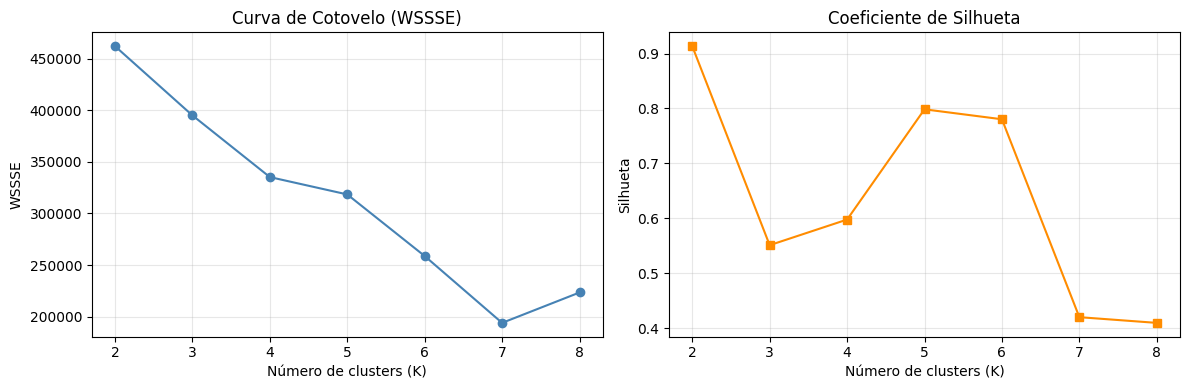

Gráfico salvo em models/kmeans_k_selection.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Curva de cotovelo ────────────────────────────────────────────────────────
axes[0].plot(df_k['k'], df_k['WSSSE'], marker='o', color='steelblue')
axes[0].set_title('Curva de Cotovelo (WSSSE)')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('WSSSE')
axes[0].grid(True, alpha=0.3)

# ── Silhueta ────────────────────────────────────────────────────────────────
axes[1].plot(df_k['k'], df_k['Silhueta'], marker='s', color='darkorange')
axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhueta')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em models/kmeans_k_selection.png')


## Modelo Final

Com base nas curvas acima, defina `K_OPTIMAL` onde o cotovelo é mais
pronunciado **e** a silhueta ainda é satisfatória. Para o dataset de voos
de 2015, esperamos 4-5 perfis principais:

| Perfil esperado | Causa dominante |
|---|---|
| Efeito cascata | `LATE_AIRCRAFT_DELAY` |
| Problema operacional | `AIRLINE_DELAY` |
| Climático | `WEATHER_DELAY` |
| Sistêmico/Espaço aéreo | `AIR_SYSTEM_DELAY` |
| Misto | múltiplas causas |

Altere `K_OPTIMAL` abaixo se a análise das curvas indicar outro valor.

In [9]:
K_OPTIMAL = 4  # ajuste conforme a análise das curvas acima

print(f'Treinando KMeans com K={K_OPTIMAL} no dataset completo...')

kmeans_final = KMeans(
    featuresCol='features',
    k=K_OPTIMAL,
    seed=42,
    maxIter=50,
    tol=1e-4
)

model_kmeans = kmeans_final.fit(df_scaled)
df_clustered = model_kmeans.transform(df_scaled)
df_clustered.cache()

print(f'Concluído ✅  |  WSSSE = {model_kmeans.summary.trainingCost:,.2f}')

# Distribuição dos clusters
print('\nDistribuição dos clusters:')
df_clustered.groupBy('prediction').count()\
    .withColumn('PCT', F.round(F.col('count') / n_delayed * 100, 2))\
    .orderBy('prediction').show()


Treinando KMeans com K=4 no dataset completo...


Concluído ✅  |  WSSSE = 3,827,887.98

Distribuição dos clusters:


+----------+------+-----+
|prediction| count|  PCT|
+----------+------+-----+
|         0|113168|10.64|
|         1|  6302| 0.59|
|         2| 90350|  8.5|
|         3|853619|80.27|
+----------+------+-----+



## Interpretação dos Clusters

O perfil de cada cluster é determinado pela **média dos minutos de atraso
por causa**. A causa com maior valor médio define o caráter do grupo.

In [10]:
# ── Perfil médio por cluster ─────────────────────────────────────────────────
perfil = (
    df_clustered
    .groupBy('prediction')
    .agg(
        F.count('*').alias('N_VOOS'),
        F.round(F.mean('ARRIVAL_DELAY'), 1).alias('ATRASO_MEDIO_MIN'),
        *[F.round(F.mean(c), 1).alias(c) for c in FEATURES_CLUSTER]
    )
    .orderBy('prediction')
    .toPandas()
)

perfil['CAUSA_DOMINANTE'] = perfil[FEATURES_CLUSTER].idxmax(axis=1)

print('Perfil dos clusters:')
print(perfil.to_string(index=False))


Perfil dos clusters:
 prediction  N_VOOS  ATRASO_MEDIO_MIN  AIR_SYSTEM_DELAY  SECURITY_DELAY  AIRLINE_DELAY  LATE_AIRCRAFT_DELAY  WEATHER_DELAY     CAUSA_DOMINANTE
          0  113168             136.1               4.7             0.0            6.9                122.4            2.1 LATE_AIRCRAFT_DELAY
          1    6302             447.6               4.9             0.0          432.9                  9.6            0.3       AIRLINE_DELAY
          2   90350             111.8               3.4             0.0          103.6                  4.6            0.2       AIRLINE_DELAY
          3  853619              40.2              15.8             0.1            8.6                 12.5            3.3    AIR_SYSTEM_DELAY


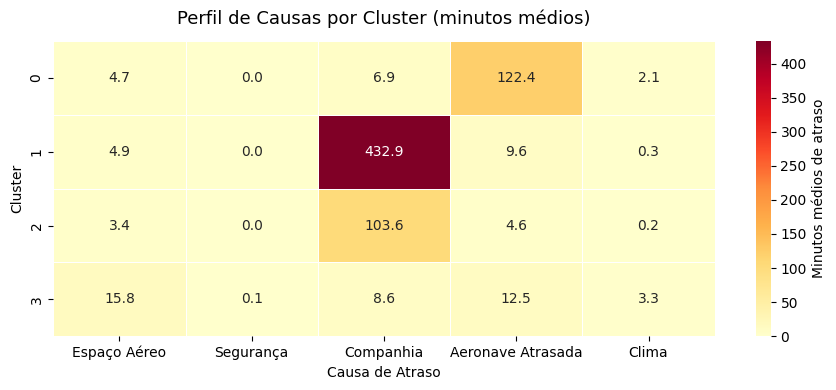

Heatmap salvo em models/kmeans_cluster_heatmap.png


In [11]:
# ── Heatmap de causas por cluster ───────────────────────────────────────────
causa_labels = {
    'AIR_SYSTEM_DELAY'   : 'Espaço Aéreo',
    'SECURITY_DELAY'     : 'Segurança',
    'AIRLINE_DELAY'      : 'Companhia',
    'LATE_AIRCRAFT_DELAY': 'Aeronave Atrasada',
    'WEATHER_DELAY'      : 'Clima',
}

heatmap_data = (
    perfil
    .set_index('prediction')[FEATURES_CLUSTER]
    .rename(columns=causa_labels)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Minutos médios de atraso'}
)
ax.set_title('Perfil de Causas por Cluster (minutos médios)', fontsize=13, pad=12)
ax.set_xlabel('Causa de Atraso')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../models/kmeans_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap salvo em models/kmeans_cluster_heatmap.png')


In [12]:
# ── Proporção de voos por companhia em cada cluster ─────────────────────────
# Ajuda a entender se algum perfil de atraso é concentrado em certas companhias
airline_cluster = (
    df_clustered
    .groupBy('AIRLINE', 'prediction')
    .count()
    .withColumnRenamed('count', 'N')
    .toPandas()
    .pivot(index='AIRLINE', columns='prediction', values='N')
    .fillna(0).astype(int)
)

# Normalizar por linha (% dos voos da companhia em cada cluster)
airline_cluster_pct = airline_cluster.div(airline_cluster.sum(axis=1), axis=0).round(3) * 100
airline_cluster_pct.columns = [f'Cluster {c}' for c in airline_cluster_pct.columns]

print('% dos voos atrasados de cada companhia por cluster:')
print(airline_cluster_pct.to_string())


% dos voos atrasados de cada companhia por cluster:
         Cluster 0  Cluster 1  Cluster 2  Cluster 3
AIRLINE                                            
AA             9.7        0.7        9.2       80.4
AS             7.5        0.4        7.9       84.2
B6            11.0        0.3        8.0       80.7
DL             8.0        1.2        9.4       81.5
EV            11.6        0.8       10.6       77.0
F9            11.8        0.6        5.4       82.2
HA             4.0        0.7        6.5       88.8
MQ            10.3        0.7        7.7       81.4
NK            10.9        0.3        5.7       83.1
OO            12.8        0.8        9.7       76.7
UA            12.8        0.5        9.0       77.7
US             6.0        0.3        8.9       84.8
VX             9.9        0.2        5.0       84.9
WN            11.2        0.3        7.2       81.3


## Persistência do Modelo

Dois artefatos são salvos:
- **`models/kmeans`**: pipeline completo (KMeans) — usado para inferência em novos dados
- **`models/kmeans_preprocessor`**: pipeline de pré-processamento (assembler + scaler)
  — necessário para transformar novos dados antes de passar pelo modelo

In [13]:
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Pré-processador (assembler + scaler)
prep_model.write().overwrite().save(f'{MODELS_DIR}/kmeans_preprocessor')
print(f'✅ Pré-processador salvo em {MODELS_DIR}/kmeans_preprocessor')

# Modelo KMeans
model_kmeans.write().overwrite().save(f'{MODELS_DIR}/kmeans')
print(f'✅ Modelo KMeans  salvo em {MODELS_DIR}/kmeans')

print(f'\nK utilizado       : {K_OPTIMAL}')
print(f'WSSSE final       : {model_kmeans.summary.trainingCost:,.2f}')
print(f'Voos agrupados    : {n_delayed:,}')
print(f'\nArtefatos salvos com sucesso ✅')


✅ Pré-processador salvo em ../models/kmeans_preprocessor
✅ Modelo KMeans  salvo em ../models/kmeans

K utilizado       : 4
WSSSE final       : 3,827,887.98
Voos agrupados    : 1,063,439

Artefatos salvos com sucesso ✅
